**IMPORTING LIBRARIES**

In [1]:
!pip install langdetect wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
})

In [4]:
df = pd.read_csv('youtube-intelligence-engine/data/raw_data.csv')

print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("=" * 55)

df.head()

  Rows         : 54,427
  Columns      : 6
  Memory usage : 24.48 MB


,author,updated_at,like_count,text,video_id,public
0,@kingsman1713,2020-03-30T00:09:44Z,41736,The guy who stay in the ship for 20 years.\n\n...,j3DuONZb3Ik,True
1,@IkanGelamaKuning,2021-08-18T15:33:15Z,37032,A husband waiting for his wife shopping feels ...,JqKa6qyVYgg,True
2,@stevedevries2891,2021-01-05T01:33:47Z,17975,My wife keeps asking me to dust my office. I'...,j3DuONZb3Ik,True
3,@joshfromdundermifflin8973,2020-03-05T18:54:19Z,15427,The scene where cooper comes back to the ship ...,j3DuONZb3Ik,True
4,@Dcook85,2014-11-24T01:48:48Z,15359,I was disappointed to see that Christopher Nol...,R1cexcjdyIE,True


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54427 entries, 0 to 54426
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   author      54427 non-null  object
 1   updated_at  54427 non-null  object
 2   like_count  54427 non-null  int64 
 3   text        54420 non-null  object
 4   video_id    54427 non-null  object
 5   public      54427 non-null  bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 2.1+ MB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
author,54427,49979,@akash.1133,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
updated_at,54427,54368,2025-08-08T16:46:19Z,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
like_count,54427.0,NaN,NaN,NaN,20.782847,373.525524,0.0,0.0,0.0,1.0,41736.0
text,54420,53016,❤,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
video_id,54427,38,j3DuONZb3Ik,8982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
public,54427,1,True,54427,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Finding missing values

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum()
})

print(missing_df)

            Missing Count
author                  0
updated_at              0
like_count              0
text                    7
video_id                0
public                  0


In [16]:
n_videos = df["video_id"].nunique()
n_comments = len(df)
avg_per_video = n_comments / n_videos if n_videos else 0

print(f"  Unique videos      : {n_videos:,}")
print(f"  Total comments     : {n_comments:,}")
print(f"  Avg comments/video : {avg_per_video:,.1f}")

  Unique videos      : 38
  Total comments     : 54,427
  Avg comments/video : 1,432.3


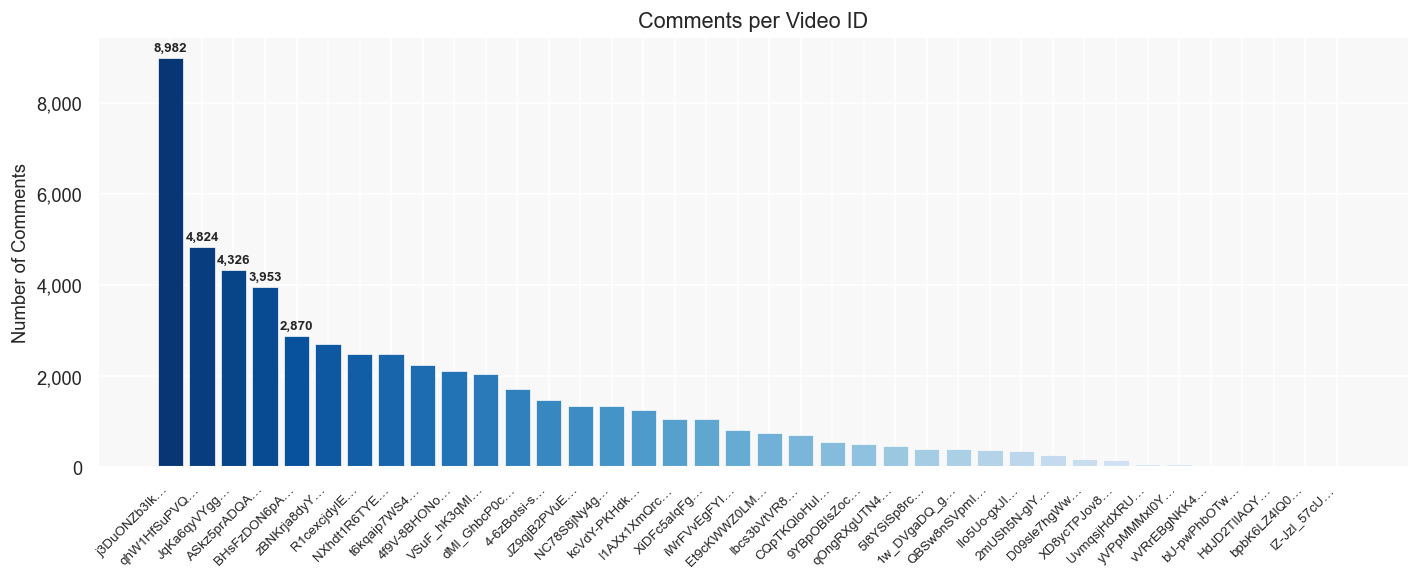


Top 10 most commented videos:
   video_id  comment_count
j3DuONZb3Ik           8982
qhW1HfSuPVQ           4824
JqKa6qyVYgg           4326
ASkz5prADQA           3953
BHsFzDON6pA           2870
zBNKrja8dyY           2706
R1cexcjdyIE           2492
NXhdt1R6TYE           2479
t6kqaip7WS4           2244
4f9V-8BHONo           2100


In [9]:
counts = df["video_id"].value_counts().reset_index()
counts.columns = ["video_id", "comment_count"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    range(len(counts)),
    counts["comment_count"],
    color=sns.color_palette("Blues_r", len(counts)),
    edgecolor="white", linewidth=0.4
)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(
    [v[:12] + "…" for v in counts["video_id"]],
    rotation=45, ha="right", fontsize=8
)
ax.set_title("Comments per Video ID")
ax.set_ylabel("Number of Comments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for i, (bar, val) in enumerate(zip(bars, counts["comment_count"])):
    if i < 5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts["comment_count"].max() * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTop 10 most commented videos:")
print(counts.head(10).to_string(index=False))

count    54420.000000
mean       142.271426
std        254.383801
min          1.000000
25%         36.000000
50%         73.000000
75%        150.000000
max       9803.000000
Name: comment_length, dtype: float64


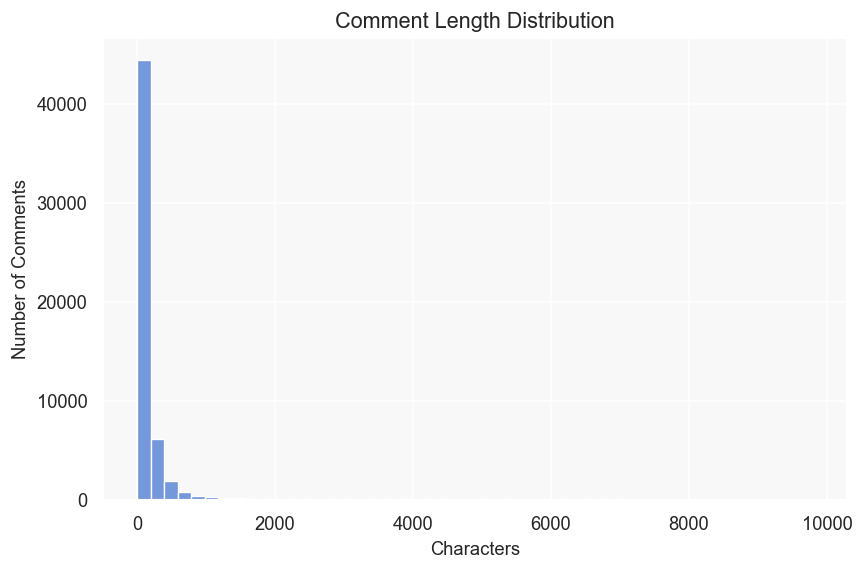

In [13]:
# Comment Length
df["comment_length"] = df["text"].str.len()

print(df["comment_length"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["comment_length"], bins=50)

plt.title("Comment Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Comments")
plt.show()

In [19]:
top_liked = (
    df[["like_count", "text", "video_id"]]
    .sort_values("like_count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_liked.index += 1
top_liked["preview"] = top_liked["text"].astype(str).str[:200]
display_df = top_liked[["like_count", "preview", "video_id"]].copy()
display_df.columns = ["Likes", "Comment (truncated)", "Video ID"]

pd.set_option("display.max_colwidth", 200)
display(display_df)

,Likes,Comment (truncated),Video ID
1,41736,The guy who stay in the ship for 20 years.\n\nHe's the king of quarantine.,j3DuONZb3Ik
2,37032,"A husband waiting for his wife shopping feels a very long time, while she feel only few minutes. A real time dilation.",JqKa6qyVYgg
3,17975,My wife keeps asking me to dust my office. I'm like - what if my dad wants to talk to me?,j3DuONZb3Ik
4,15427,"The scene where cooper comes back to the ship after the ocean planet incident , and sees all the video transmissions from his children gets me every time.",j3DuONZb3Ik
5,15359,I was disappointed to see that Christopher Nolan did not add a disclaimer to the movie warning people not to go into black holes. Now everyone's going to be doing it.,R1cexcjdyIE
6,14772,Did you also find Interstellar confusing?,j3DuONZb3Ik
7,14772,Did you also find Interstellar confusing?,j3DuONZb3Ik
8,14460,This movie was made waaaaay too early for its time.,j3DuONZb3Ik
9,13627,This shit was filmed in my hometown. If I recall correctly production gave all the fucking crops they actually had to grow for the opening scenes of the film to local farmers to boost the local ec...,I1AXx1XmQrc
10,10878,You know it's a legendary film when you can make a breakdown of it almost 9 years after its release and people are still thirsty for it.,zBNKrja8dyY


Word count stats:
count    54,427.00
mean         25.67
std          44.74
min           0.00
25%           7.00
50%          13.00
75%          27.00
max       1,619.00
Name: word_count, dtype: object

Character count stats:
count    54,427.00
mean        142.25
std         254.37
min           1.00
25%          36.00
50%          72.00
75%         150.00
max       9,803.00
Name: char_count, dtype: object


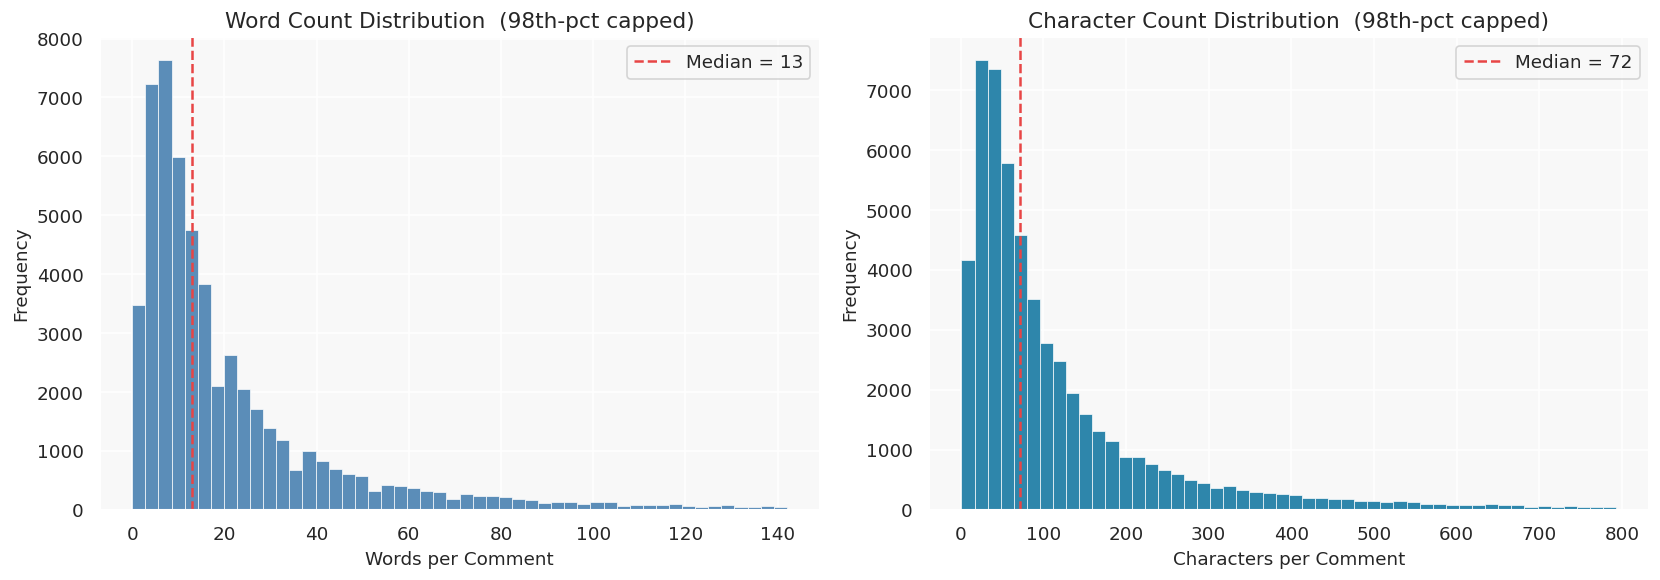

In [20]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["text"].astype(str).apply(len)

print("Word count stats:")
print(df["word_count"].describe().apply(lambda x: f"{x:,.2f}"))
print("\nCharacter count stats:")
print(df["char_count"].describe().apply(lambda x: f"{x:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
wc_cap = df["word_count"].quantile(0.98)
ax.hist(df["word_count"][df["word_count"] <= wc_cap],
        bins=50, color="#5B8DB8", edgecolor="white", linewidth=0.4)
ax.set_title("Word Count Distribution  (98th-pct capped)")
ax.set_xlabel("Words per Comment")
ax.set_ylabel("Frequency")
med_wc = df["word_count"].median()
ax.axvline(med_wc, color="#E84545", linestyle="--", linewidth=1.5, label=f"Median = {med_wc:.0f}")
ax.legend()

ax = axes[1]
cc_cap = df["char_count"].quantile(0.98)
ax.hist(df["char_count"][df["char_count"] <= cc_cap],
        bins=50, color="#2E86AB", edgecolor="white", linewidth=0.4)
ax.set_title("Character Count Distribution  (98th-pct capped)")
ax.set_xlabel("Characters per Comment")
ax.set_ylabel("Frequency")
med_cc = df["char_count"].median()
ax.axvline(med_cc, color="#E84545", linestyle="--", linewidth=1.5, label=f"Median = {med_cc:.0f}")
ax.legend()

plt.tight_layout()
plt.show()


Languages detected (sample of 10,000):
language  count
      en   8452
      ml    161
      id    147
 unknown    120
      so     94
      af     84
      nl     81
      et     79
      it     77
      tl     67
      fr     64
      de     63
      sw     53
      ro     46
      sv     44

 English: 84.5%


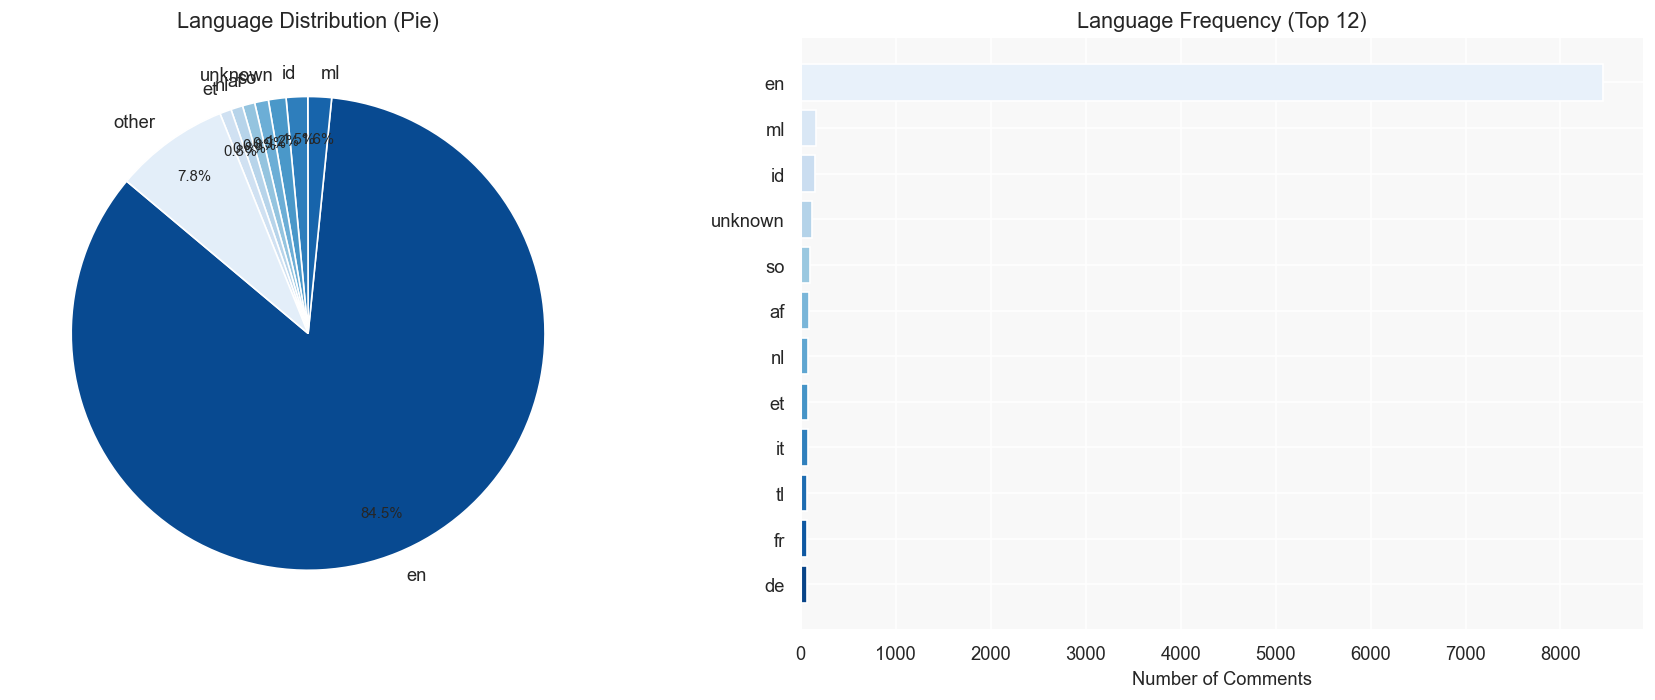

In [14]:
def safe_detect(text):
    try:
        return detect(str(text))
    except Exception:
        return "unknown"

sample_size = min(10_000, len(df))
sample_idx = df.sample(sample_size, random_state=42).index
df.loc[sample_idx, "language"] = df.loc[sample_idx, "text"].apply(safe_detect)

lang_counts = df["language"].value_counts().reset_index()
lang_counts.columns = ["language", "count"]

print(f"\nLanguages detected (sample of {sample_size:,}):")
print(lang_counts.head(15).to_string(index=False))

en_pct = (lang_counts.loc[lang_counts["language"] == "en", "count"].values[0] /
          lang_counts["count"].sum() * 100) if "en" in lang_counts["language"].values else 0
print(f"\n English: {en_pct:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_langs = lang_counts.head(8)
other_count = lang_counts.iloc[8:]["count"].sum()
if other_count > 0:
    pie_data = pd.concat([top_langs,
                           pd.DataFrame([{"language": "other", "count": other_count}])],
                          ignore_index=True)
else:
    pie_data = top_langs

ax = axes[0]
colors = sns.color_palette("Blues_r", len(pie_data))
wedges, texts, autotexts = ax.pie(
    pie_data["count"], labels=pie_data["language"],
    autopct="%1.1f%%", startangle=140,
    colors=colors, pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Language Distribution (Pie)")

ax = axes[1]
ax.barh(lang_counts.head(12)["language"][::-1],
        lang_counts.head(12)["count"][::-1],
        color=sns.color_palette("Blues_r", 12))
ax.set_title("Language Frequency (Top 12)")
ax.set_xlabel("Number of Comments")

plt.tight_layout()
plt.show()

In [22]:
total_dupes = df.duplicated(subset=["text"]).sum()
pct_dupes = total_dupes / len(df) * 100

print(f"  Total rows           : {len(df):,}")
print(f"  Exact duplicate texts: {total_dupes:,}")
print(f"  Duplicate rate       : {pct_dupes:.2f}%")
print(f"  Full-row duplicates  : {df.duplicated().sum():,}")

if total_dupes > 0:
    print("\nSample duplicated comments:")
    dup_texts = df[df.duplicated(subset=["text"], keep=False)]["text"].value_counts().head(5)
    for txt, cnt in dup_texts.items():
        print(f"  [{cnt}x] {str(txt)[:120]}")

  Total rows           : 54,427
  Exact duplicate texts: 1,410
  Duplicate rate       : 2.59%
  Full-row duplicates  : 12

Sample duplicated comments:
  [46x] ❤
  [46x] This is actually a really good video
  [28x] Snail race Malayalam explanation cheyu
  [28x] This is actually a very good video
  [22x] This is actually a very good video.


In [15]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "it", "this", "that", "was", "are", "be", "have",
    "has", "do", "did", "will", "would", "could", "should", "i", "you",
    "he", "she", "they", "we", "my", "your", "his", "her", "our", "its",
    "not", "no", "so", "just", "like", "as", "if", "up", "what", "when",
    "who", "how", "all", "very", "more", "from", "one", "by", "there",
    "about", "been", "also", "which", "than", "into", "can", "me", "him",
    "them", "their", "were", "dont", "im", "its", "know", "think", "really"
}

def tokenize(text):
    tokens = re.findall(r"[a-z]{3,}", str(text).lower())
    return [t for t in tokens if t not in STOPWORDS]


all_words = []
for text in df["text"]:
    all_words.extend(tokenize(text))

word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])

print(f"Total unique words : {len(word_freq):,}")
print(f"Total word tokens  : {sum(word_freq.values()):,}")
print(top_words.to_string(index=False))

Total unique words : 38,052
Total word tokens  : 731,707
        word  count
       movie  15169
        time  12736
       video   5380
      planet   4480
        hole   4330
       black   4326
        love   4242
      cooper   4140
interstellar   4058
       space   3554
        film   3457
        good   3423
       earth   3410
         why   3393
      future   3345
         out   3088
     because   3077
        only   2946
      people   2796
      humans   2795
       great   2768
         get   2724
         don   2622
       years   2618
        even   2547
     gravity   2537
       still   2447
       watch   2398
       first   2395
         see   2376


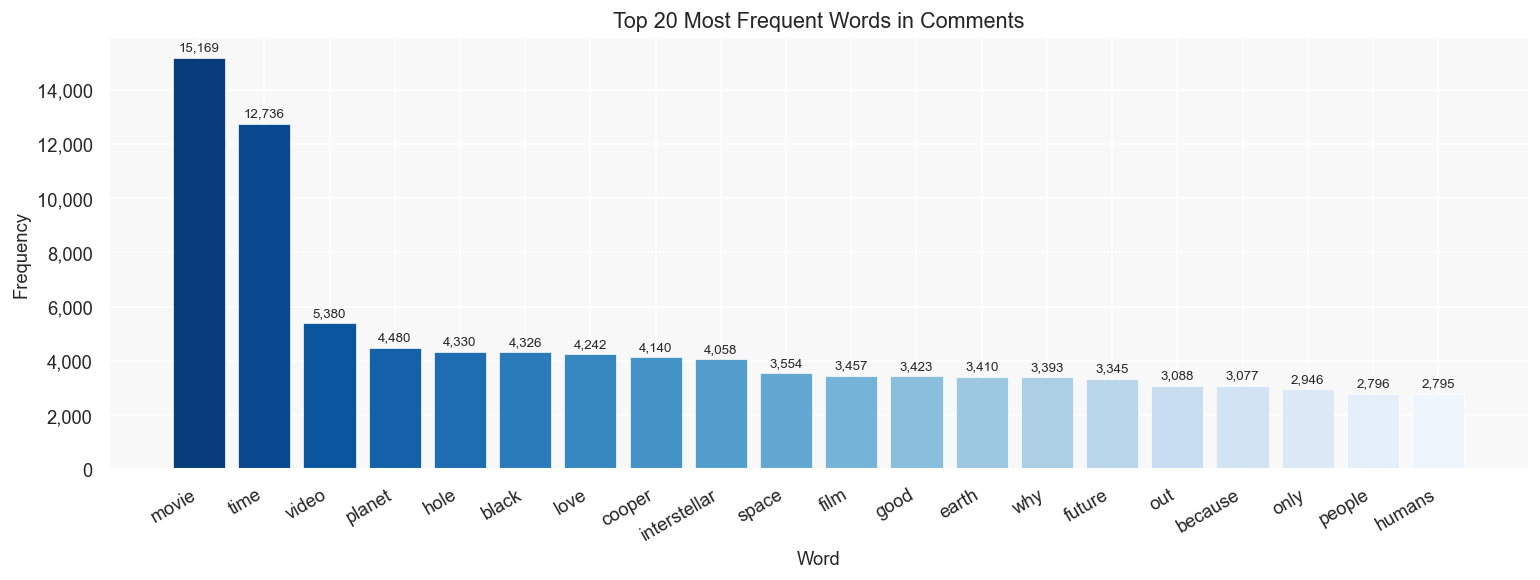

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
top20 = top_words.head(20)
bars = ax.bar(top20["word"], top20["count"],
              color=sns.color_palette("Blues_r", 20), edgecolor="white", linewidth=0.4)
ax.set_title("Top 20 Most Frequent Words in Comments")
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, top20["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + top20["count"].max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

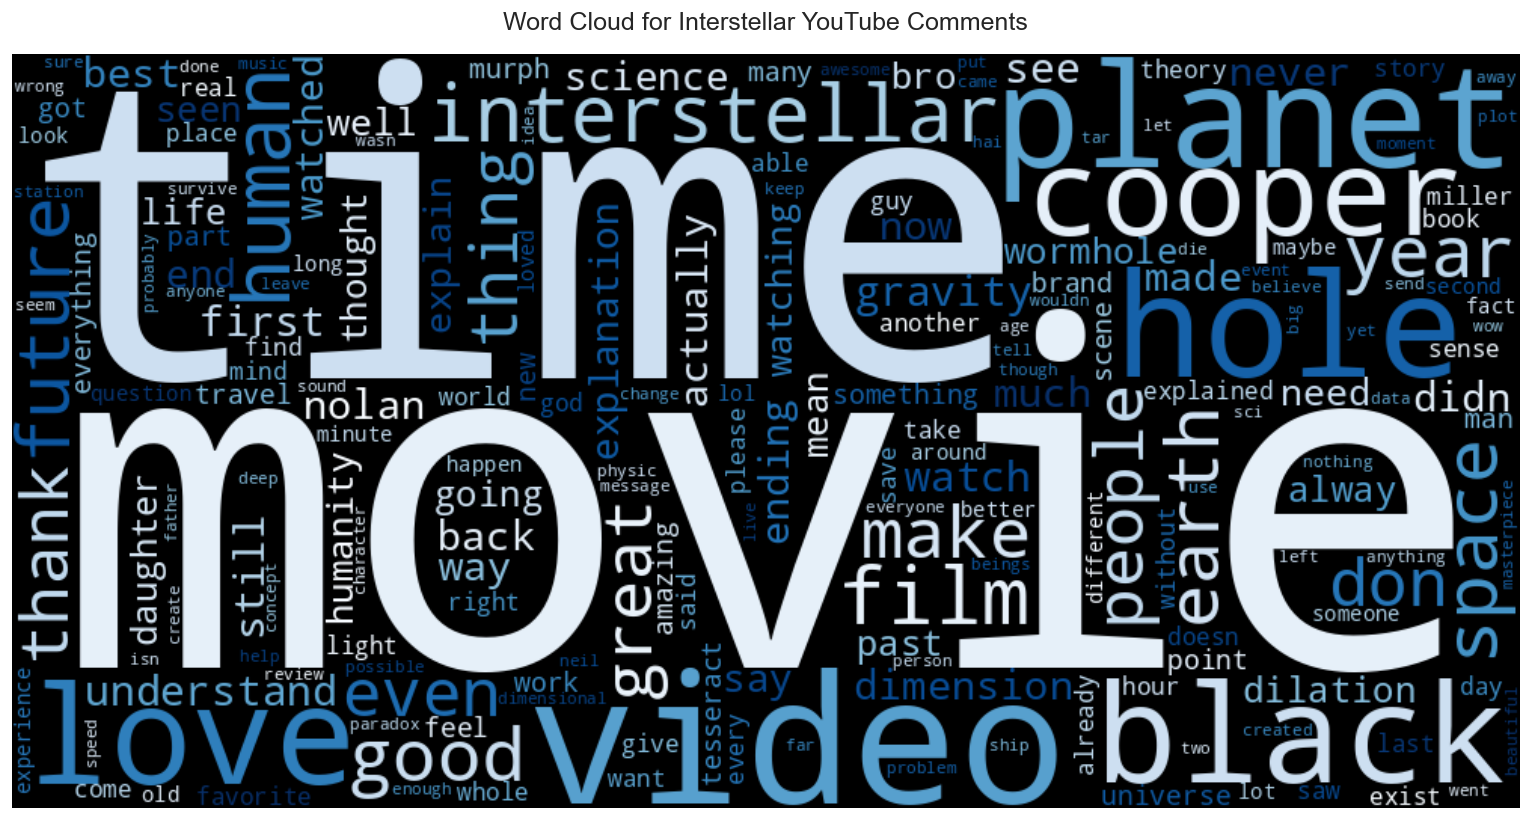

In [16]:
wc_text = " ".join([w for w in all_words if len(w) > 2])

wordcloud = WordCloud(
    width=1000, height=500,
    background_color="black",
    colormap="Blues",
    max_words=200,
    collocations=False,
    random_state=42
).generate(wc_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud for Interstellar YouTube Comments", fontsize=15, pad=15)
plt.tight_layout()
plt.show()

Valid datetime values: 54,427 / 54,427


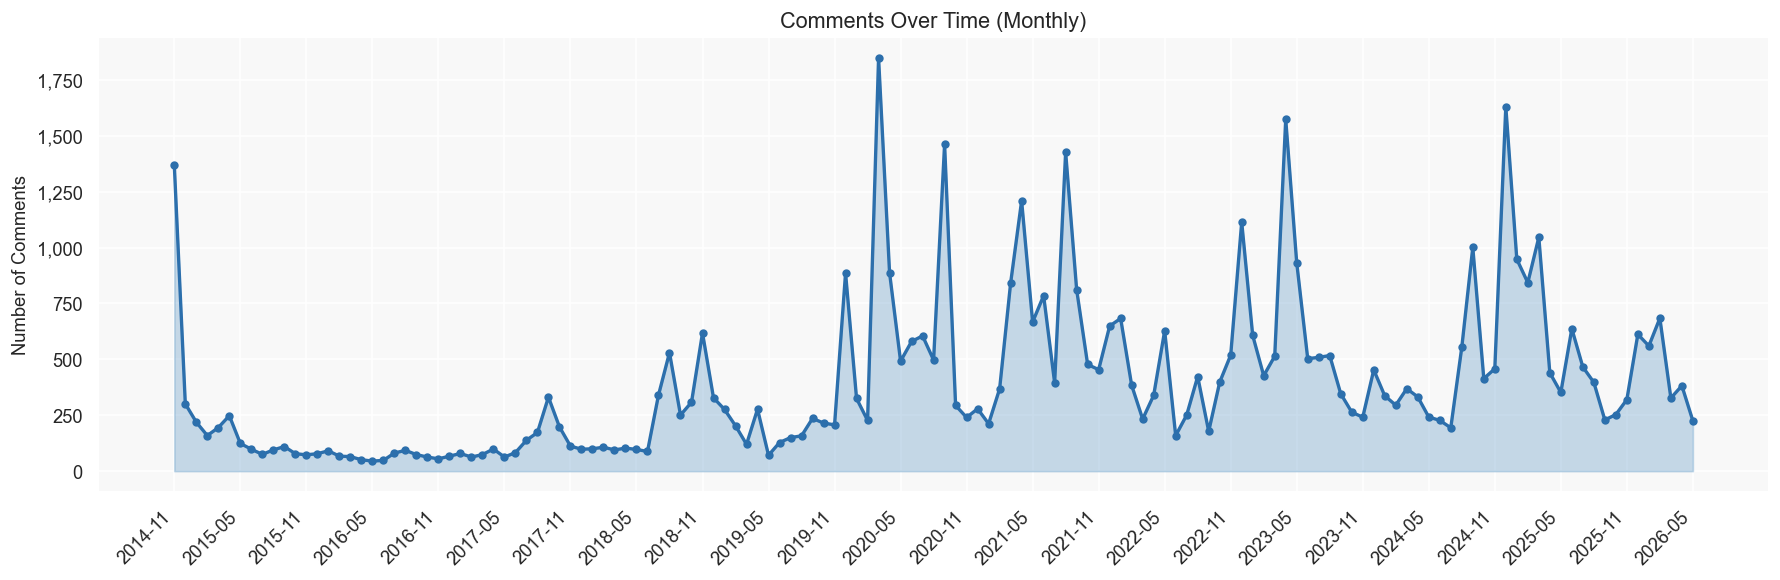


Peak month: 2020-03 — 1,848 comments


In [18]:
df["updated_at"] = pd.to_datetime(df["updated_at"], errors="coerce", utc=True)
n_valid_dates = df["updated_at"].notna().sum()
print(f"Valid datetime values: {n_valid_dates:,} / {len(df):,}")

df["year_month"] = df["updated_at"].dt.to_period("M")
monthly = df.groupby("year_month").size().reset_index(name="comment_count")
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(range(len(monthly)), monthly["comment_count"],
                alpha=0.3, color="#4C8CBF")
ax.plot(range(len(monthly)), monthly["comment_count"],
        color="#2C6FAC", linewidth=2, marker="o", markersize=4)

step = max(1, len(monthly) // 20)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly["year_month_str"].iloc[::step], rotation=45, ha="right")
ax.set_title("Comments Over Time (Monthly)")
ax.set_ylabel("Number of Comments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

peak = monthly.loc[monthly["comment_count"].idxmax()]
print(f"\nPeak month: {peak['year_month_str']} — {peak['comment_count']:,} comments")

In [20]:
print("=" * 55)
print("           EDA SUMMARY REPORT")
print("=" * 55)
print(f"  Dataset rows            : {len(df):,}")
print(f"  Dataset columns         : {df.shape[1]}")
print(f"  Unique videos           : {df['video_id'].nunique():,}")
print(f"  Mean likes/comment      : {df['like_count'].mean():.2f}")
print(f"  Max likes on a comment  : {df['like_count'].max():,}")

top_lang = df["language"].value_counts().idxmax()
top_lang_pct = df["language"].value_counts().max() / df["language"].notna().sum() * 100
print(f"  Dominant language       : {top_lang} ({top_lang_pct:.1f}%)")

dupes = df.duplicated(subset=["text"]).sum()
print(f"  Duplicate comments      : {dupes:,} ({dupes/len(df)*100:.2f}%)")
print(f"  Total missing values    : {df.isnull().sum().sum():,}")
print("=" * 55)


           EDA SUMMARY REPORT
  Dataset rows            : 54,427
  Dataset columns         : 9
  Unique videos           : 38
  Mean likes/comment      : 20.78
  Max likes on a comment  : 41,736
  Dominant language       : en (84.5%)
  Duplicate comments      : 1,410 (2.59%)
  Total missing values    : 44,441
